# 07 — Future Match Predictions
## What Does the Model Forecast for Upcoming Matches?
---
**Purpose:** Apply the trained Random Forest to all scheduled matches and display
forecast weather, predicted goals, and over/under probabilities.

**Inputs:** `data/final/remaining_match_forecasts.csv` (forecast weather + predictions)
**Model:** Random Forest trained on the 28 completed matches with confirmed weather
**Weather:** Open-Meteo Forecast API — rerun `pipeline.py` for updated forecasts

**Caveats:**
- Knockout-stage matches with TBD teams show NULL predictions
- Forecast accuracy degrades beyond 7 days from kickoff
- All CV R² are negative at n = 28 — treat predictions as directional, not precise


## 0. Setup & Imports

In [1]:
%matplotlib inline
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

from pathlib import Path as _Path
_NB_DIR   = _Path.cwd()
BASE      = str(_NB_DIR.parent)
RAW       = str(_NB_DIR.parent / "data" / "raw")
PROCESSED = str(_NB_DIR.parent / "data" / "processed")
FINAL     = str(_NB_DIR.parent / "data" / "final")
EXTERNAL  = str(_NB_DIR.parent / "data" / "external")
print("Ready.")

Ready.


## 1. Load Forecast Data

In [2]:
forecast = pd.read_csv(os.path.join(FINAL, "remaining_match_forecasts.csv"))
ext      = pd.read_csv(os.path.join(EXTERNAL, "world_cup_matches.csv"))

# Join with full schedule for stage info
upcoming = ext[ext["match_status"] != "Completed"].copy()
pred_sub = forecast[["match_id","predicted_total_goals","probability_over_2_5_goals",
                      "forecast_temperature_c","forecast_wbgt_c",
                      "forecast_precipitation_mm"]].copy() if "match_id" in forecast.columns else forecast.copy()

# Merge if match_id present in both
if "match_id" in forecast.columns and "match_id" in upcoming.columns:
    upcoming = upcoming.merge(pred_sub, on="match_id", how="left")

print(f"Upcoming matches: {len(upcoming)}")
print(f"  - Scheduled (teams known): {(upcoming['match_status']=='Scheduled').sum()}")
print(f"  - TBD (teams unknown):     {(upcoming['match_status']=='TBD').sum()}")
print()
print("Columns available:", list(upcoming.columns[:10]), "...")
upcoming[["match_id","match_date","home_team","away_team","stage","match_status"]].head(8)

Upcoming matches: 68
  - Scheduled (teams known): 36
  - TBD (teams unknown):     32

Columns available: ['match_id', 'stage', 'group', 'match_date', 'kickoff_time_local', 'kickoff_time_utc', 'timezone', 'home_team', 'away_team', 'home_goals'] ...


,match_id,match_date,home_team,away_team,stage,match_status
0,WC2026-037,2026-06-21,Spain,Saudi Arabia,Group Stage,Scheduled
1,WC2026-038,2026-06-21,Belgium,Iran,Group Stage,Scheduled
2,WC2026-039,2026-06-21,Uruguay,Cape Verde,Group Stage,Scheduled
3,WC2026-040,2026-06-21,New Zealand,Egypt,Group Stage,Scheduled
4,WC2026-041,2026-06-22,Argentina,Austria,Group Stage,Scheduled
5,WC2026-042,2026-06-22,France,Iraq,Group Stage,Scheduled
6,WC2026-043,2026-06-22,Norway,Senegal,Group Stage,Scheduled
7,WC2026-044,2026-06-22,Jordan,Algeria,Group Stage,Scheduled


## 2. Forecast Weather Overview

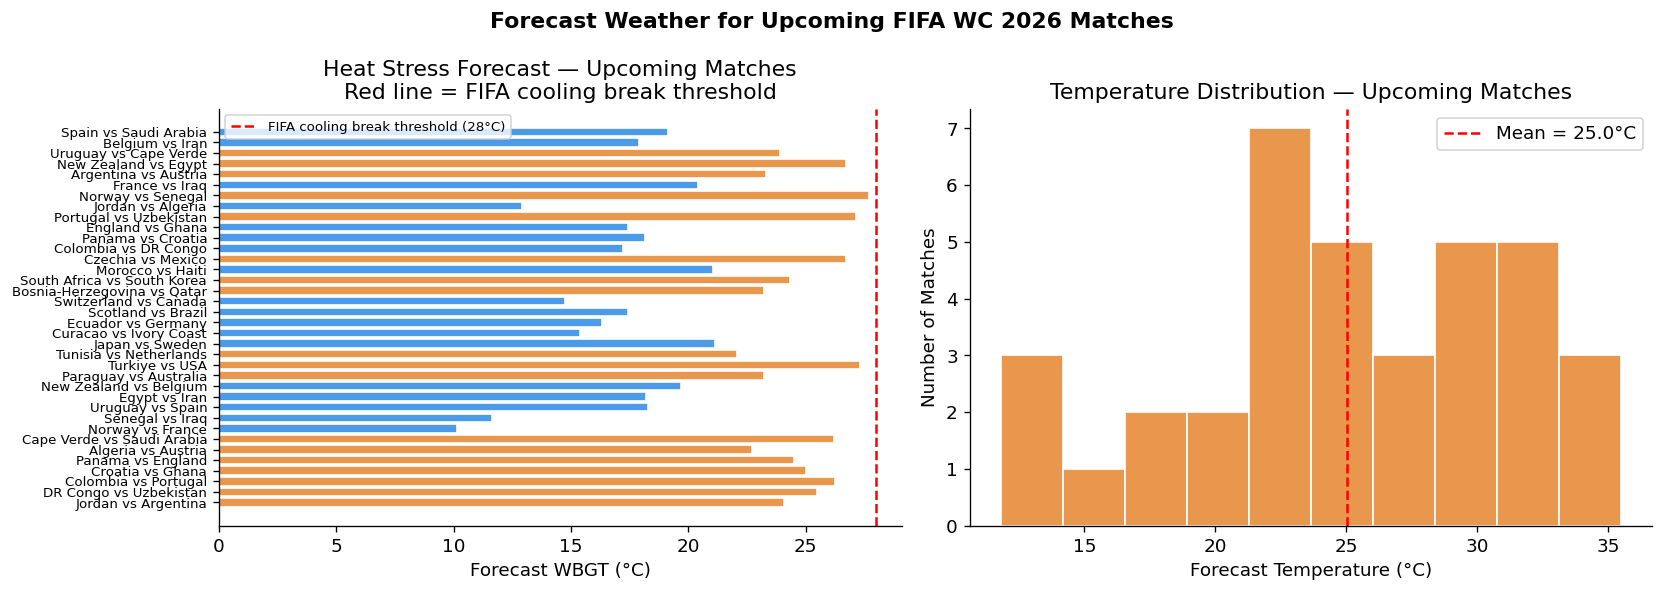

In [3]:
# Forecast WBGT by upcoming match (heat stress)
has_wbgt = "forecast_wbgt_c" in upcoming.columns or "wbgt_c" in upcoming.columns
wbgt_col = "forecast_wbgt_c" if "forecast_wbgt_c" in upcoming.columns else "wbgt_c"

if has_wbgt and upcoming[wbgt_col].notna().any():
    sub = upcoming.dropna(subset=[wbgt_col]).copy()
    sub = sub.sort_values("match_date")
    sub["label"] = sub["home_team"].fillna("TBD") + " vs " + sub["away_team"].fillna("TBD")
    sub["label"] = sub["label"].str[:30]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # WBGT by match
    colors = ["#E05C5C" if v >= 28 else "#E8974C" if v >= 22 else "#4C9BE8"
              for v in sub[wbgt_col]]
    axes[0].barh(range(len(sub)), sub[wbgt_col], color=colors, edgecolor="white")
    axes[0].axvline(28, color="red", ls="--", lw=1.5, label="FIFA cooling break threshold (28°C)")
    axes[0].set_yticks(range(len(sub)))
    axes[0].set_yticklabels(sub["label"], fontsize=8)
    axes[0].set_xlabel("Forecast WBGT (°C)")
    axes[0].set_title("Heat Stress Forecast — Upcoming Matches\nRed line = FIFA cooling break threshold")
    axes[0].legend(fontsize=8)
    axes[0].invert_yaxis()

    # Temperature distribution
    temp_col = "forecast_temperature_c" if "forecast_temperature_c" in upcoming.columns else None
    if temp_col and upcoming[temp_col].notna().any():
        axes[1].hist(upcoming[temp_col].dropna(), bins=10, color="#E8974C", edgecolor="white")
        axes[1].axvline(upcoming[temp_col].mean(), color="red", ls="--",
                        label=f"Mean = {upcoming[temp_col].mean():.1f}°C")
        axes[1].set_xlabel("Forecast Temperature (°C)")
        axes[1].set_ylabel("Number of Matches")
        axes[1].set_title("Temperature Distribution — Upcoming Matches")
        axes[1].legend()

    fig.suptitle("Forecast Weather for Upcoming FIFA WC 2026 Matches", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Forecast WBGT not found in dataset. Run pipeline.py to generate forecasts.")
    print("Available columns:", list(upcoming.columns))

## 3. Predicted Goals — Upcoming Matches

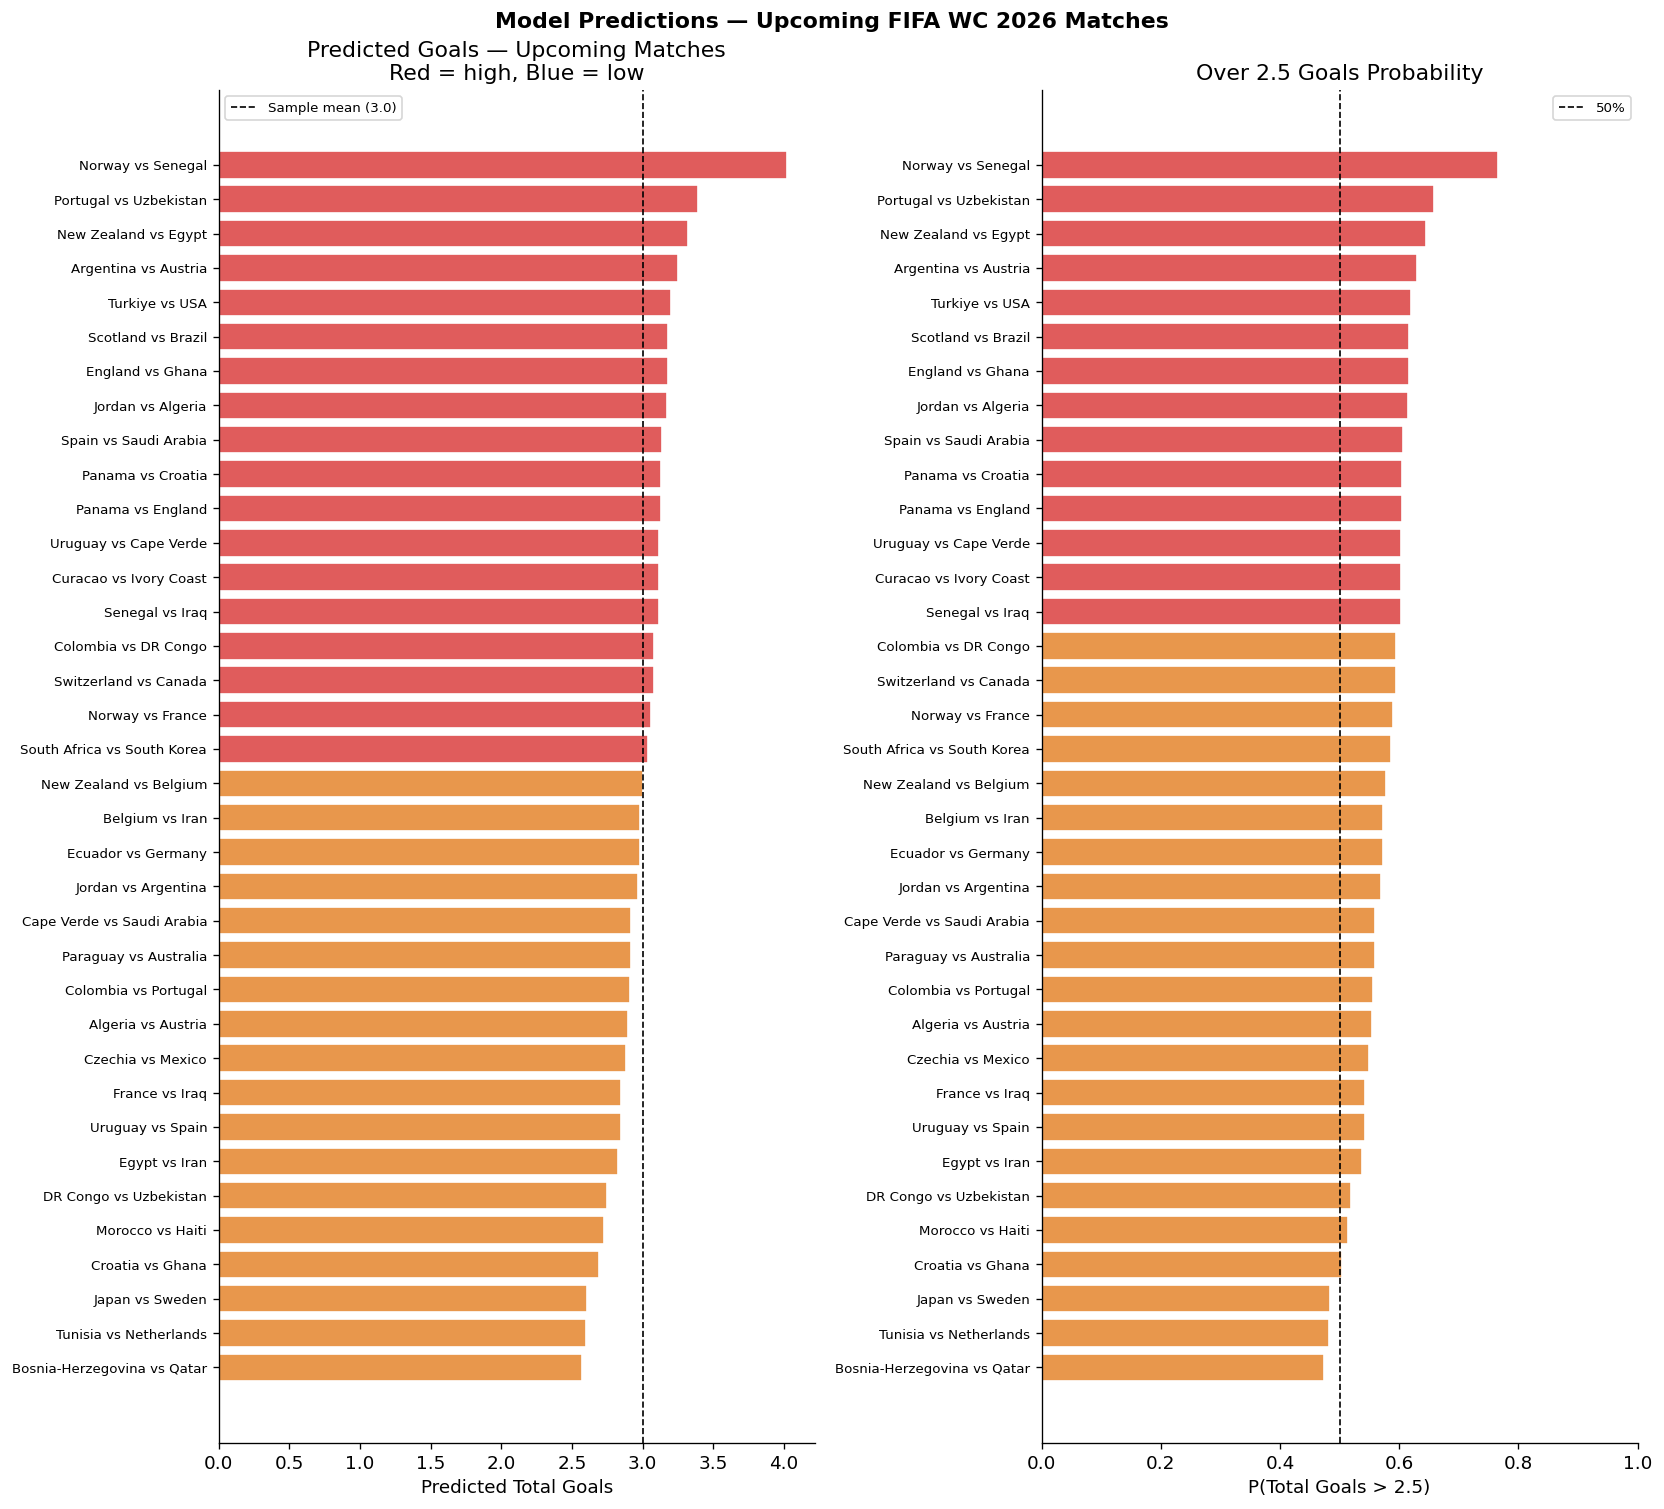

Matches with predictions: 36
Average predicted goals:  3.02
Highest predicted:        Norway vs Senegal (4.02)
Lowest predicted:         Bosnia-Herzegovina vs Qatar (2.57)


In [4]:
pred_col = "predicted_total_goals" if "predicted_total_goals" in upcoming.columns else None
prob_col = "probability_over_2_5_goals" if "probability_over_2_5_goals" in upcoming.columns else None

if pred_col and upcoming[pred_col].notna().any():
    sub = upcoming.dropna(subset=[pred_col]).copy().sort_values(pred_col, ascending=False)
    sub["label"] = sub["home_team"].fillna("TBD") + " vs " + sub["away_team"].fillna("TBD")
    sub["label"] = sub["label"].str[:32]

    fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(sub)*0.3 + 2)))

    # Predicted goals bar
    bar_cols = ["#E05C5C" if v > 3.0 else "#E8974C" if v > 2.5 else "#4C9BE8"
                for v in sub[pred_col]]
    axes[0].barh(range(len(sub)), sub[pred_col], color=bar_cols, edgecolor="white")
    axes[0].axvline(3.0, color="black", ls="--", lw=1, label="Sample mean (3.0)")
    axes[0].set_yticks(range(len(sub)))
    axes[0].set_yticklabels(sub["label"], fontsize=8)
    axes[0].set_xlabel("Predicted Total Goals")
    axes[0].set_title("Predicted Goals — Upcoming Matches\nRed = high, Blue = low")
    axes[0].legend(fontsize=8)
    axes[0].invert_yaxis()

    # Over 2.5 probability
    if prob_col and sub[prob_col].notna().any():
        prob_colors = ["#E05C5C" if v > 0.6 else "#E8974C" if v > 0.45 else "#4C9BE8"
                       for v in sub[prob_col]]
        axes[1].barh(range(len(sub)), sub[prob_col], color=prob_colors, edgecolor="white")
        axes[1].axvline(0.5, color="black", ls="--", lw=1, label="50%")
        axes[1].set_xlim(0, 1)
        axes[1].set_yticks(range(len(sub)))
        axes[1].set_yticklabels(sub["label"], fontsize=8)
        axes[1].set_xlabel("P(Total Goals > 2.5)")
        axes[1].set_title("Over 2.5 Goals Probability")
        axes[1].legend(fontsize=8)
        axes[1].invert_yaxis()

    fig.suptitle("Model Predictions — Upcoming FIFA WC 2026 Matches", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"Matches with predictions: {sub[pred_col].notna().sum()}")
    print(f"Average predicted goals:  {sub[pred_col].mean():.2f}")
    print(f"Highest predicted:        {sub.iloc[0]['label']} ({sub.iloc[0][pred_col]:.2f})")
    print(f"Lowest predicted:         {sub.iloc[-1]['label']} ({sub.iloc[-1][pred_col]:.2f})")
else:
    print("No predictions found. Run pipeline.py to generate forecasts.")
    print("Forecast file columns:", list(forecast.columns[:10]))

---
## 4. TBD Matches — Knockout Stage

Knockout-stage matches cannot be forecast until both teams are confirmed
after their group stage concludes (June 27).

Once teams are confirmed, run `python src/pipeline.py` to:
1. Fetch forecast weather for each knockout venue + kickoff time
2. Build the feature vector (ELO difference, rolling averages from group stage, travel distance)
3. Apply the trained Random Forest
4. Update `remaining_match_forecasts.csv`

---
## Confidence Note

All predictions carry high uncertainty at this stage:
- n = 28 training samples → model CV R² < 0 (sample mean outperforms all models)
- Forecast weather accuracy degrades beyond 7 days from kickoff
- Predictions should be read as **directional trends**, not precise point estimates
- Rerun `pipeline.py` closer to each match for the most accurate forecast

→ Next: `08_linkedin_insights.ipynb` — the 3 key findings worth sharing publicly.
